# belief eye neural analysis


## imports

In [10]:
%reload_ext autoreload
%autoreload 2

In [11]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [12]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA

In [13]:
# misc
import pickle
from collections import defaultdict

In [14]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

In [15]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [16]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [17]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [18]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [19]:
df.columns

Index(['trial', 'session', 'fullon', 'density', 'eye_hori', 'eye_vert',
       'ff_hori', 'ff_vert', 'fx', 'fy', 'mx', 'my', 'mv', 'mw', 'PPC',
       'PPC_var', 'PFC', 'PFC_var', 'MST', 'MST_var', 'error', 'error_sign',
       'target_angle', 'target_distance', 'state', 'action', 'task',
       'likelihood', 'belief', 'rawcov', 'bmx', 'bmy', 'heading',
       'belief_heading', 'timer', 'countdown', 'belief_ff_hori',
       'belief_ff_vert', 'angle_from_start', 'belief_angle_from_start',
       'relcov', 'state_error', 'belief_error', 'time_ratio'],
      dtype='object')

In [20]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

# plots

In [33]:
def analyze_belief_neural_correlation(timedf, sessdf):
    """
    Analyze correlation between belief (belief_ff_hori) and neural activity (PPC).
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    
    Returns:
    --------
    correlations : array
        Correlation coefficients between belief and each neural dimension
    p_values : array
        P-values for correlation tests
    """
    # Extract belief data
    belief = np.array(timedf.belief)
    
    # Extract neural activity data
    neural = np.vstack(timedf.PPC)
    
    # Calculate dimensions
    n_samples = len(belief)
    n_neurons = neural.shape[1]
    
    print(f"Number of time samples: {n_samples}")
    print(f"Number of neurons: {n_neurons}")
    
    # Calculate correlation for each neural dimension
    correlations = []
    p_values = []
    
    for i in range(n_neurons):
        corr, p_val = pearsonr(belief, neural[:, i])
        correlations.append(corr)
        p_values.append(p_val)
    
    # Convert to numpy arrays
    correlations = np.array(correlations)
    p_values = np.array(p_values)
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print(f"Mean correlation: {np.mean(correlations):.4f}")
    print(f"Median correlation: {np.median(correlations):.4f}")
    print(f"Min correlation: {np.min(correlations):.4f}")
    print(f"Max correlation: {np.max(correlations):.4f}")
    
    # Count significant correlations
    significant = p_values < 0.05
    print(f"\nSignificantly correlated neurons (p < 0.05): {sum(significant)}/{n_neurons} ({sum(significant)/n_neurons*100:.1f}%)")
    
    # Count positive vs negative correlations
    pos_corr = correlations > 0
    print(f"Positively correlated neurons: {sum(pos_corr)}/{n_neurons} ({sum(pos_corr)/n_neurons*100:.1f}%)")
    print(f"Negatively correlated neurons: {sum(~pos_corr)}/{n_neurons} ({sum(~pos_corr)/n_neurons*100:.1f}%)")
    
    # Count significant positive and negative correlations
    sig_pos = (correlations > 0) & significant
    sig_neg = (correlations < 0) & significant
    print(f"Significantly positively correlated neurons: {sum(sig_pos)}/{n_neurons} ({sum(sig_pos)/n_neurons*100:.1f}%)")
    print(f"Significantly negatively correlated neurons: {sum(sig_neg)}/{n_neurons} ({sum(sig_neg)/n_neurons*100:.1f}%)")
    
    return correlations, p_values

# Call the function
correlations, p_values = analyze_belief_neural_correlation(timedf, sessdf)

Number of time samples: 400117
Number of neurons: 112

Summary Statistics:
Mean correlation: 0.0132
Median correlation: 0.0122
Min correlation: -0.1723
Max correlation: 0.2660

Significantly correlated neurons (p < 0.05): 108/112 (96.4%)
Positively correlated neurons: 64/112 (57.1%)
Negatively correlated neurons: 48/112 (42.9%)
Significantly positively correlated neurons: 62/112 (55.4%)
Significantly negatively correlated neurons: 46/112 (41.1%)


In [36]:
def find_optimal_neural_format(timedf, sessdf, n_samples=50000, n_folds=5, random_state=42):
    """
    Find optimal neural data format and window size using cross-validation.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    n_samples : int
        Number of samples to use for analysis (to keep computation time reasonable)
    n_folds : int
        Number of cross-validation folds
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    results_dict : dict
        Dictionary containing cross-validation results for different formats
    """
    # Extract belief data
    belief = np.array(timedf.belief)
    
    # Extract raw neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(belief)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(random_state)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        belief = belief[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Analyzing {n_neurons} neurons with different processing methods using {n_folds}-fold cross-validation")
    
    # Define formats to test
    window_sizes = [3, 5, 10, 20, 50]
    alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
    formats = {
        'raw': {'name': 'Raw Activity'},
    }
    
    # Add moving average formats
    for w in window_sizes:
        formats[f'ma_{w}'] = {'name': f'Moving Average (window={w})'}
    
    # Add moving std formats
    for w in window_sizes:
        formats[f'mstd_{w}'] = {'name': f'Moving STD (window={w})'}
    
    # Add EMA formats
    for a in alpha_values:
        formats[f'ema_{a}'] = {'name': f'EMA (alpha={a})'}
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    # Process neural data for each format
    neural_data_formats = {}
    
    # Raw data
    neural_data_formats['raw'] = neural_raw
    
    # Moving averages
    for w in window_sizes:
        neural_ma = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neural_ma[:, i] = np.convolve(neural_raw[:, i], np.ones(w)/w, mode='same')
        neural_data_formats[f'ma_{w}'] = neural_ma
    
    # Moving standard deviations
    for w in window_sizes:
        neural_mstd = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            # Use rolling window approach
            neuron_data = neural_raw[:, i]
            for j in range(len(neuron_data)):
                if j < w:
                    window_data = neuron_data[:j+1]
                else:
                    window_data = neuron_data[j-w+1:j+1]
                neural_mstd[j, i] = np.std(window_data)
        neural_data_formats[f'mstd_{w}'] = neural_mstd
    
    # EMAs
    for a in alpha_values:
        neural_ema = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neuron_data = neural_raw[:, i]
            ema_vals = [neuron_data[0]]  # Start with first value
            
            for j in range(1, len(neuron_data)):
                ema_val = a * neuron_data[j] + (1 - a) * ema_vals[-1]
                ema_vals.append(ema_val)
            
            neural_ema[:, i] = np.array(ema_vals)
        neural_data_formats[f'ema_{a}'] = neural_ema
    
    # Perform cross-validation
    results = {}
    
    for format_key, format_data in neural_data_formats.items():
        format_name = formats[format_key]['name']
        print(f"\nEvaluating: {format_name}")
        
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(belief):
            # Split data
            X_train, X_test = format_data[train_idx], format_data[test_idx]
            y_train, y_test = belief[train_idx], belief[test_idx]
            
            # Train model on each neuron and combine predictions
            neuron_predictions = np.zeros((len(y_test), n_neurons))
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                neuron_predictions[:, i] = neuron_pred
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(test_corr)
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(np.abs(neuron_test_corrs))
            cv_corrs.append(mean_abs_corr)
            
            # Combine predictions from all neurons using a meta-model
            meta_model = LinearRegression()
            meta_model.fit(neuron_predictions, y_test)
            
            # Calculate combined prediction error
            combined_pred = meta_model.predict(neuron_predictions)
            mse = mean_squared_error(y_test, combined_pred)
            cv_scores.append(mse)
        
        # Store results
        results[format_key] = {
            'name': format_name,
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[format_key]['mean_cv_mse']:.6f} ± {results[format_key]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[format_key]['mean_cv_corr']:.6f} ± {results[format_key]['std_cv_corr']:.6f}")
    
    # Sort results by mean correlation
    sorted_results = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    
    print("\n=== Results Summary (Sorted by Correlation) ===")
    for i, (format_key, result) in enumerate(sorted_results):
        print(f"{i+1}. {result['name']}: |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, sorted_results

# Call the function
results, sorted_results = find_optimal_neural_format(timedf, sessdf, n_samples=5000)

Using 5000 samples out of 400117 total samples
Analyzing 112 neurons with different processing methods using 5-fold cross-validation

Evaluating: Raw Activity
  Mean CV MSE: 363.880904 ± 35.074749
  Mean CV |r|: 0.055430 ± 0.001964

Evaluating: Moving Average (window=3)
  Mean CV MSE: 344.845632 ± 31.756548
  Mean CV |r|: 0.063480 ± 0.004706

Evaluating: Moving Average (window=5)
  Mean CV MSE: 353.581942 ± 35.154075
  Mean CV |r|: 0.063632 ± 0.006377

Evaluating: Moving Average (window=10)
  Mean CV MSE: 385.282813 ± 36.782589
  Mean CV |r|: 0.057517 ± 0.006708

Evaluating: Moving Average (window=20)
  Mean CV MSE: 423.203426 ± 35.726007
  Mean CV |r|: 0.047006 ± 0.005083

Evaluating: Moving Average (window=50)
  Mean CV MSE: 439.009171 ± 28.315611
  Mean CV |r|: 0.040137 ± 0.005336

Evaluating: Moving STD (window=3)
  Mean CV MSE: 368.125700 ± 36.273433
  Mean CV |r|: 0.057555 ± 0.003332

Evaluating: Moving STD (window=5)
  Mean CV MSE: 373.053508 ± 33.158199
  Mean CV |r|: 0.058760 

Using 5000 samples out of 400117 total samples
Testing 9 EMA alpha values using 5-fold cross-validation

Evaluating EMA with alpha = 0.1
  Mean CV MSE: 444.464800 ± 41.098002
  Mean CV |r|: 0.056684 ± 0.004507

Evaluating EMA with alpha = 0.2
  Mean CV MSE: 407.050059 ± 38.329855
  Mean CV |r|: 0.065946 ± 0.005209

Evaluating EMA with alpha = 0.3
  Mean CV MSE: 389.403284 ± 36.411293
  Mean CV |r|: 0.068984 ± 0.005044

Evaluating EMA with alpha = 0.4
  Mean CV MSE: 382.985170 ± 35.685958
  Mean CV |r|: 0.069298 ± 0.004331

Evaluating EMA with alpha = 0.5
  Mean CV MSE: 382.981677 ± 35.884972
  Mean CV |r|: 0.068103 ± 0.003625

Evaluating EMA with alpha = 0.6
  Mean CV MSE: 386.723516 ± 36.719498
  Mean CV |r|: 0.066092 ± 0.002983

Evaluating EMA with alpha = 0.7
  Mean CV MSE: 392.743829 ± 37.911122
  Mean CV |r|: 0.063625 ± 0.002502

Evaluating EMA with alpha = 0.8
  Mean CV MSE: 400.261454 ± 39.242588
  Mean CV |r|: 0.060982 ± 0.002239

Evaluating EMA with alpha = 0.9
  Mean CV MSE: 

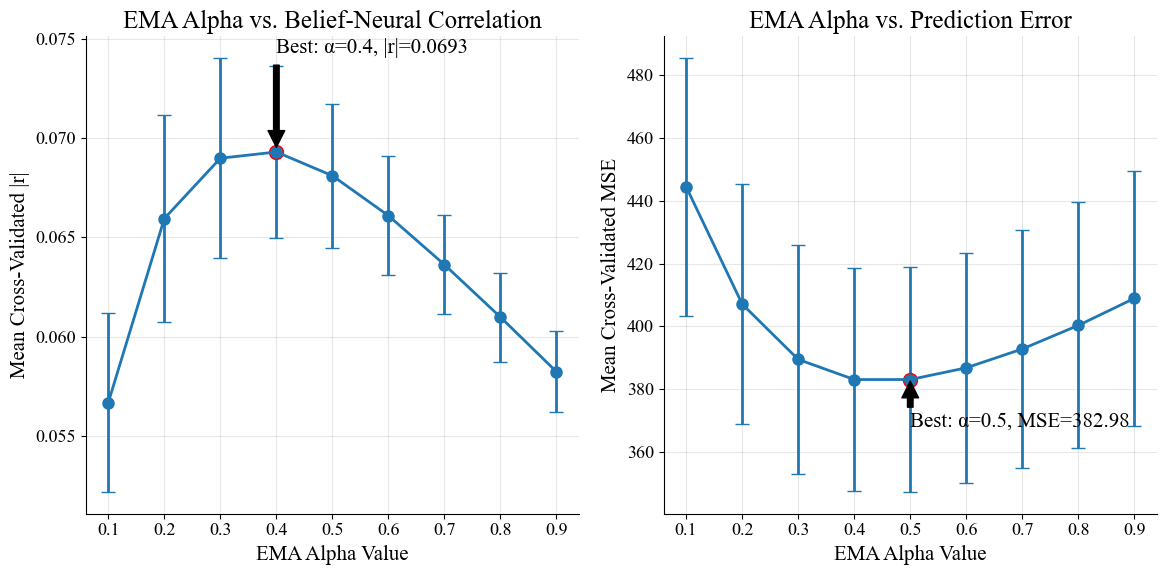


=== Results Summary (Sorted by Correlation) ===
1. Alpha = 0.4: |r| = 0.069298, MSE = 382.985170
2. Alpha = 0.3: |r| = 0.068984, MSE = 389.403284
3. Alpha = 0.5: |r| = 0.068103, MSE = 382.981677
4. Alpha = 0.6: |r| = 0.066092, MSE = 386.723516
5. Alpha = 0.2: |r| = 0.065946, MSE = 407.050059
6. Alpha = 0.7: |r| = 0.063625, MSE = 392.743829
7. Alpha = 0.8: |r| = 0.060982, MSE = 400.261454
8. Alpha = 0.9: |r| = 0.058234, MSE = 408.880813
9. Alpha = 0.1: |r| = 0.056684, MSE = 444.464800


In [40]:
def analyze_ema_alpha_trend(timedf, sessdf, alpha_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_samples=5000, n_folds=5):
    """
    Analyze how different EMA alpha values affect the cross-validated correlation
    between neural activity and belief.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha_values : list
        List of EMA alpha values to test
    n_samples : int
        Number of samples to use for analysis
    n_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary containing cross-validation results for different alpha values
    """
    # Extract belief data
    belief = np.array(timedf.belief)
    
    # Extract neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(belief)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(42)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        belief = belief[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Testing {len(alpha_values)} EMA alpha values using {n_folds}-fold cross-validation")
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Store results for each alpha value
    results = {}
    
    for alpha in alpha_values:
        print(f"\nEvaluating EMA with alpha = {alpha}")
        
        # Process neural data with current alpha
        neural_ema = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neuron_data = neural_raw[:, i]
            ema_vals = [neuron_data[0]]  # Start with first value
            
            for j in range(1, len(neuron_data)):
                ema_val = alpha * neuron_data[j] + (1 - alpha) * ema_vals[-1]
                ema_vals.append(ema_val)
            
            neural_ema[:, i] = np.array(ema_vals)
        
        # Perform cross-validation
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(belief):
            # Split data
            X_train, X_test = neural_ema[train_idx], neural_ema[test_idx]
            y_train, y_test = belief[train_idx], belief[test_idx]
            
            # Train model on each neuron and get correlations
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(abs(test_corr))  # Use absolute correlation
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(neuron_test_corrs)
            cv_corrs.append(mean_abs_corr)
            
            # Use all neurons together to predict belief
            multi_model = LinearRegression()
            multi_model.fit(X_train, y_train)
            
            # Calculate MSE
            y_pred = multi_model.predict(X_test)
            mse = np.mean((y_test - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Store results
        results[alpha] = {
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[alpha]['mean_cv_mse']:.6f} ± {results[alpha]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[alpha]['mean_cv_corr']:.6f} ± {results[alpha]['std_cv_corr']:.6f}")
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot correlation trend
    ax1 = plt.subplot(1, 2, 1)
    alphas = sorted(results.keys())
    corrs = [results[alpha]['mean_cv_corr'] for alpha in alphas]
    corr_stds = [results[alpha]['std_cv_corr'] for alpha in alphas]
    
    ax1.errorbar(alphas, corrs, yerr=corr_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax1.set_xlabel('EMA Alpha Value')
    ax1.set_ylabel('Mean Cross-Validated |r|')
    ax1.set_title('EMA Alpha vs. Belief-Neural Correlation')
    ax1.grid(True, alpha=0.3)
    
    # Add points for best values
    max_corr_idx = np.argmax(corrs)
    max_corr_alpha = alphas[max_corr_idx]
    max_corr = corrs[max_corr_idx]
    ax1.plot(max_corr_alpha, max_corr, 'o', color='red', markersize=10)
    ax1.annotate(f'Best: α={max_corr_alpha}, |r|={max_corr:.4f}', 
                xy=(max_corr_alpha, max_corr), 
                xytext=(max_corr_alpha, max_corr+0.005),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Plot MSE trend
    ax2 = plt.subplot(1, 2, 2)
    mses = [results[alpha]['mean_cv_mse'] for alpha in alphas]
    mse_stds = [results[alpha]['std_cv_mse'] for alpha in alphas]
    
    ax2.errorbar(alphas, mses, yerr=mse_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax2.set_xlabel('EMA Alpha Value')
    ax2.set_ylabel('Mean Cross-Validated MSE')
    ax2.set_title('EMA Alpha vs. Prediction Error')
    ax2.grid(True, alpha=0.3)
    
    # Add points for best values
    min_mse_idx = np.argmin(mses)
    min_mse_alpha = alphas[min_mse_idx]
    min_mse = mses[min_mse_idx]
    ax2.plot(min_mse_alpha, min_mse, 'o', color='red', markersize=10)
    ax2.annotate(f'Best: α={min_mse_alpha}, MSE={min_mse:.2f}', 
                xy=(min_mse_alpha, min_mse), 
                xytext=(min_mse_alpha, min_mse-15),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary in sorted order
    print("\n=== Results Summary (Sorted by Correlation) ===")
    sorted_alphas = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    for i, (alpha, result) in enumerate(sorted_alphas):
        print(f"{i+1}. Alpha = {alpha}: |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, alphas, corrs, mses

# Call the function
results, alphas, corrs, mses = analyze_ema_alpha_trend(timedf, sessdf)

Using 5000 samples out of 400117 total samples
Testing 10 moving average window sizes using 5-fold cross-validation

Evaluating moving average with window size = 2
  Mean CV MSE: 405.302035 ± 33.616372
  Mean CV |r|: 0.063540 ± 0.002735

Evaluating moving average with window size = 3
  Mean CV MSE: 399.342243 ± 39.442655
  Mean CV |r|: 0.063480 ± 0.004706

Evaluating moving average with window size = 5
  Mean CV MSE: 405.521818 ± 40.630007
  Mean CV |r|: 0.063632 ± 0.006377

Evaluating moving average with window size = 10
  Mean CV MSE: 443.677374 ± 44.432114
  Mean CV |r|: 0.057517 ± 0.006708

Evaluating moving average with window size = 15
  Mean CV MSE: 474.224926 ± 46.036298
  Mean CV |r|: 0.049835 ± 0.005705

Evaluating moving average with window size = 20
  Mean CV MSE: 483.384657 ± 41.464720
  Mean CV |r|: 0.047006 ± 0.005083

Evaluating moving average with window size = 30
  Mean CV MSE: 499.379473 ± 46.479891
  Mean CV |r|: 0.042492 ± 0.005775

Evaluating moving average with w

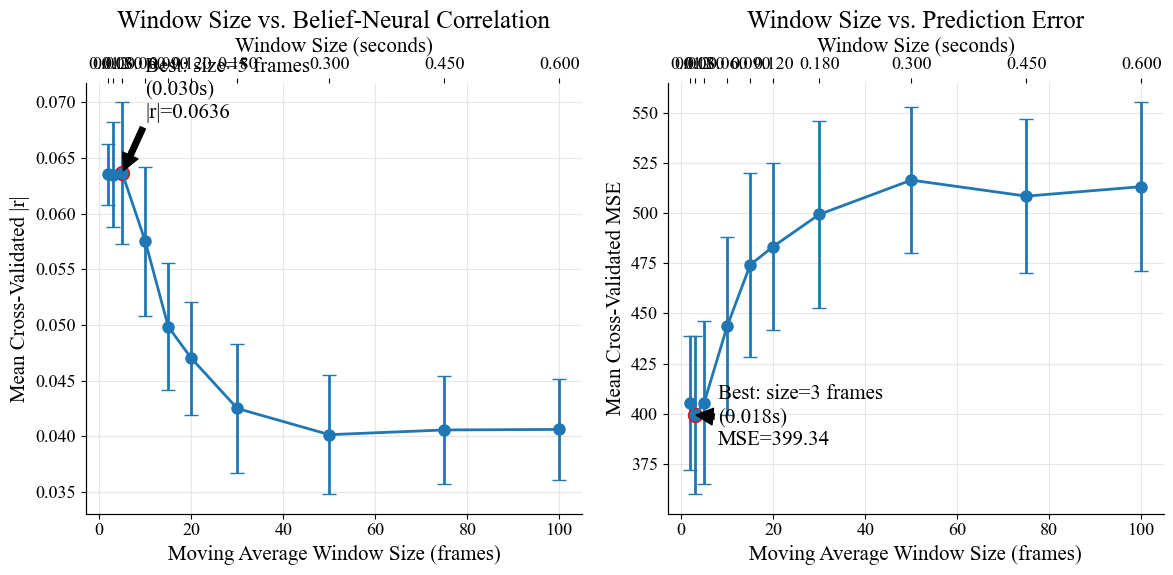


=== Results Summary (Sorted by Correlation) ===
1. Window Size = 5 (0.030s): |r| = 0.063632, MSE = 405.521818
2. Window Size = 2 (0.012s): |r| = 0.063540, MSE = 405.302035
3. Window Size = 3 (0.018s): |r| = 0.063480, MSE = 399.342243
4. Window Size = 10 (0.060s): |r| = 0.057517, MSE = 443.677374
5. Window Size = 15 (0.090s): |r| = 0.049835, MSE = 474.224926
6. Window Size = 20 (0.120s): |r| = 0.047006, MSE = 483.384657
7. Window Size = 30 (0.180s): |r| = 0.042492, MSE = 499.379473
8. Window Size = 100 (0.600s): |r| = 0.040608, MSE = 513.253357
9. Window Size = 75 (0.450s): |r| = 0.040560, MSE = 508.524540
10. Window Size = 50 (0.300s): |r| = 0.040137, MSE = 516.517182


In [42]:
def analyze_ma_window_trend(timedf, sessdf, window_sizes=[2, 3, 5, 10, 15, 20, 30, 50, 75, 100], n_samples=5000, n_folds=5):
    """
    Analyze how different moving average window sizes affect the cross-validated correlation
    between neural activity and belief.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    window_sizes : list
        List of moving average window sizes to test
    n_samples : int
        Number of samples to use for analysis
    n_folds : int
        Number of cross-validation folds
    
    Returns:
    --------
    results : dict
        Dictionary containing cross-validation results for different window sizes
    """
    # Extract belief data
    belief = np.array(timedf.belief)
    
    # Extract neural activity data
    neural_raw = np.vstack(timedf.PPC)
    n_neurons = neural_raw.shape[1]
    total_samples = len(belief)
    
    # Subsample if needed
    if n_samples < total_samples:
        np.random.seed(42)
        sample_indices = np.random.choice(total_samples, n_samples, replace=False)
        sample_indices.sort()  # Keep temporal order
        belief = belief[sample_indices]
        neural_raw = neural_raw[sample_indices]
        print(f"Using {n_samples} samples out of {total_samples} total samples")
    else:
        print(f"Using all {total_samples} samples")
    
    print(f"Testing {len(window_sizes)} moving average window sizes using {n_folds}-fold cross-validation")
    
    # Setup cross-validation
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Store results for each window size
    results = {}
    
    for window in window_sizes:
        print(f"\nEvaluating moving average with window size = {window}")
        
        # Process neural data with current window size
        neural_ma = np.zeros_like(neural_raw)
        for i in range(n_neurons):
            neural_ma[:, i] = np.convolve(neural_raw[:, i], np.ones(window)/window, mode='same')
        
        # Perform cross-validation
        cv_scores = []
        cv_corrs = []
        
        for train_idx, test_idx in kf.split(belief):
            # Split data
            X_train, X_test = neural_ma[train_idx], neural_ma[test_idx]
            y_train, y_test = belief[train_idx], belief[test_idx]
            
            # Train model on each neuron and get correlations
            neuron_test_corrs = []
            
            for i in range(n_neurons):
                # Create and train model
                model = LinearRegression()
                model.fit(X_train[:, i].reshape(-1, 1), y_train)
                
                # Make predictions
                neuron_pred = model.predict(X_test[:, i].reshape(-1, 1))
                
                # Calculate correlation on test set
                test_corr, _ = pearsonr(y_test, neuron_pred)
                neuron_test_corrs.append(abs(test_corr))  # Use absolute correlation
            
            # Calculate mean absolute correlation
            mean_abs_corr = np.mean(neuron_test_corrs)
            cv_corrs.append(mean_abs_corr)
            
            # Use all neurons together to predict belief
            multi_model = LinearRegression()
            multi_model.fit(X_train, y_train)
            
            # Calculate MSE
            y_pred = multi_model.predict(X_test)
            mse = np.mean((y_test - y_pred) ** 2)
            cv_scores.append(mse)
        
        # Store results
        results[window] = {
            'mean_cv_mse': np.mean(cv_scores),
            'std_cv_mse': np.std(cv_scores),
            'mean_cv_corr': np.mean(cv_corrs),
            'std_cv_corr': np.std(cv_corrs)
        }
        
        print(f"  Mean CV MSE: {results[window]['mean_cv_mse']:.6f} ± {results[window]['std_cv_mse']:.6f}")
        print(f"  Mean CV |r|: {results[window]['mean_cv_corr']:.6f} ± {results[window]['std_cv_corr']:.6f}")
    
    # Convert window sizes to time in seconds
    time_bin_size = 0.006  # seconds per time bin
    window_times = [w * time_bin_size for w in window_sizes]
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Plot correlation trend
    ax1 = plt.subplot(1, 2, 1)
    windows = sorted(results.keys())
    times = [w * time_bin_size for w in windows]
    corrs = [results[window]['mean_cv_corr'] for window in windows]
    corr_stds = [results[window]['std_cv_corr'] for window in windows]
    
    # First x-axis: window size in frames
    ax1.errorbar(windows, corrs, yerr=corr_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax1.set_xlabel('Moving Average Window Size (frames)')
    ax1.set_ylabel('Mean Cross-Validated |r|')
    ax1.set_title('Window Size vs. Belief-Neural Correlation')
    ax1.grid(True, alpha=0.3)
    
    # Add second x-axis: window size in seconds
    ax1_sec = ax1.twiny()
    ax1_sec.set_xlim(ax1.get_xlim())
    ax1_sec.set_xticks(windows)
    ax1_sec.set_xticklabels([f'{w*time_bin_size:.3f}' for w in windows])
    ax1_sec.set_xlabel('Window Size (seconds)')
    
    # Add points for best values
    max_corr_idx = np.argmax(corrs)
    max_corr_window = windows[max_corr_idx]
    max_corr = corrs[max_corr_idx]
    ax1.plot(max_corr_window, max_corr, 'o', color='red', markersize=10)
    ax1.annotate(f'Best: size={max_corr_window} frames\n({max_corr_window*time_bin_size:.3f}s)\n|r|={max_corr:.4f}', 
                xy=(max_corr_window, max_corr), 
                xytext=(max_corr_window + 5, max_corr+0.005),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Plot MSE trend
    ax2 = plt.subplot(1, 2, 2)
    mses = [results[window]['mean_cv_mse'] for window in windows]
    mse_stds = [results[window]['std_cv_mse'] for window in windows]
    
    # First x-axis: window size in frames
    ax2.errorbar(windows, mses, yerr=mse_stds, fmt='o-', capsize=5, linewidth=2, markersize=8)
    ax2.set_xlabel('Moving Average Window Size (frames)')
    ax2.set_ylabel('Mean Cross-Validated MSE')
    ax2.set_title('Window Size vs. Prediction Error')
    ax2.grid(True, alpha=0.3)
    
    # Add second x-axis: window size in seconds
    ax2_sec = ax2.twiny()
    ax2_sec.set_xlim(ax2.get_xlim())
    ax2_sec.set_xticks(windows)
    ax2_sec.set_xticklabels([f'{w*time_bin_size:.3f}' for w in windows])
    ax2_sec.set_xlabel('Window Size (seconds)')
    
    # Add points for best values
    min_mse_idx = np.argmin(mses)
    min_mse_window = windows[min_mse_idx]
    min_mse = mses[min_mse_idx]
    ax2.plot(min_mse_window, min_mse, 'o', color='red', markersize=10)
    ax2.annotate(f'Best: size={min_mse_window} frames\n({min_mse_window*time_bin_size:.3f}s)\nMSE={min_mse:.2f}', 
                xy=(min_mse_window, min_mse), 
                xytext=(min_mse_window + 5, min_mse-15),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary in sorted order
    print("\n=== Results Summary (Sorted by Correlation) ===")
    sorted_windows = sorted(results.items(), key=lambda x: x[1]['mean_cv_corr'], reverse=True)
    for i, (window, result) in enumerate(sorted_windows):
        print(f"{i+1}. Window Size = {window} ({window*time_bin_size:.3f}s): |r| = {result['mean_cv_corr']:.6f}, MSE = {result['mean_cv_mse']:.6f}")
    
    return results, windows, corrs, mses

# Call the function
results, windows, corrs, mses = analyze_ma_window_trend(timedf, sessdf)

In [45]:
def add_neural_ema(timedf, sessdf, alpha=0.4):
    """
    Add exponential moving average of neural activity with specified alpha
    to timedf and sessdf dataframes.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha : float
        Alpha parameter for exponential moving average
    
    Returns:
    --------
    timedf : DataFrame
        Updated timedf with neuralEMA column
    sessdf : DataFrame
        Updated sessdf with neuralEMA column
    """
    print(f"Adding neural EMA with alpha={alpha} to dataframes")
    
    # Process neural data in timedf
    neural_raw = np.vstack(timedf.PPC)
    n_samples, n_neurons = neural_raw.shape
    
    # Calculate EMA for each neuron
    neural_ema = np.zeros_like(neural_raw)
    for i in range(n_neurons):
        neuron_data = neural_raw[:, i]
        ema_vals = [neuron_data[0]]  # Start with first value
        
        for j in range(1, len(neuron_data)):
            ema_val = alpha * neuron_data[j] + (1 - alpha) * ema_vals[-1]
            ema_vals.append(ema_val)
        
        neural_ema[:, i] = np.array(ema_vals)
    
    # Add to timedf
    timedf['neuralEMA'] = list(neural_ema)
    
    # Process for sessdf (need to split by trial)
    # First, get the trial indices from timedf to sessdf mapping
    print("Organizing neural EMA by trial...")
    
    # Get the lengths of each trial's PPC data
    ppc_lengths = sessdf.PPC.apply(len)
    
    # Create empty list to hold the neural EMA for each trial
    trial_neural_ema = []
    
    # Current position in the timedf
    current_pos = 0
    
    # For each trial, extract the corresponding section from the neural_ema
    for length in ppc_lengths:
        if current_pos + length <= len(neural_ema):
            # Extract the section for this trial
            trial_section = neural_ema[current_pos:current_pos+length]
            trial_neural_ema.append(trial_section)
            current_pos += length
        else:
            # Handle edge case (shouldn't happen if data is consistent)
            print("Warning: Trial length inconsistency detected")
            trial_neural_ema.append(np.zeros((length, n_neurons)))
    
    # Add to sessdf
    sessdf['neuralEMA'] = trial_neural_ema
    
    print(f"Added neuralEMA column to both dataframes")
    print(f"Shape of timedf.neuralEMA[0]: {timedf.neuralEMA[0].shape}")
    if len(trial_neural_ema) > 0:
        print(f"Shape of sessdf.neuralEMA[0]: {sessdf.neuralEMA[0].shape}")
    
    return timedf, sessdf

# Call the function
timedf, sessdf = add_neural_ema(timedf, sessdf, alpha=0.4)

Adding neural EMA with alpha=0.4 to dataframes
Organizing neural EMA by trial...
Added neuralEMA column to both dataframes
Shape of timedf.neuralEMA[0]: (112,)


KeyError: 0

--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,), Timer=(400117,), Countdown=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Z-scoring smoothed data per channel (Globally)...

--- Time-Binned Analysis for Trial Time Ratio ---

Processing Bin 1/50 (Trial Time Ratio: 0.00 to 0.02)...
  Samples in bin: 9346
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.3592, p=1.03e-282
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent): 0.3589, p=4.42e-282

Processing Bin 2/50 (Trial Time Ratio: 0.02 to 0.04)...
  Samples in bin: 8598
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.6650, p=0.00e+00
  Calculating Independent Belief Encoding (Residuals -> Belief)..

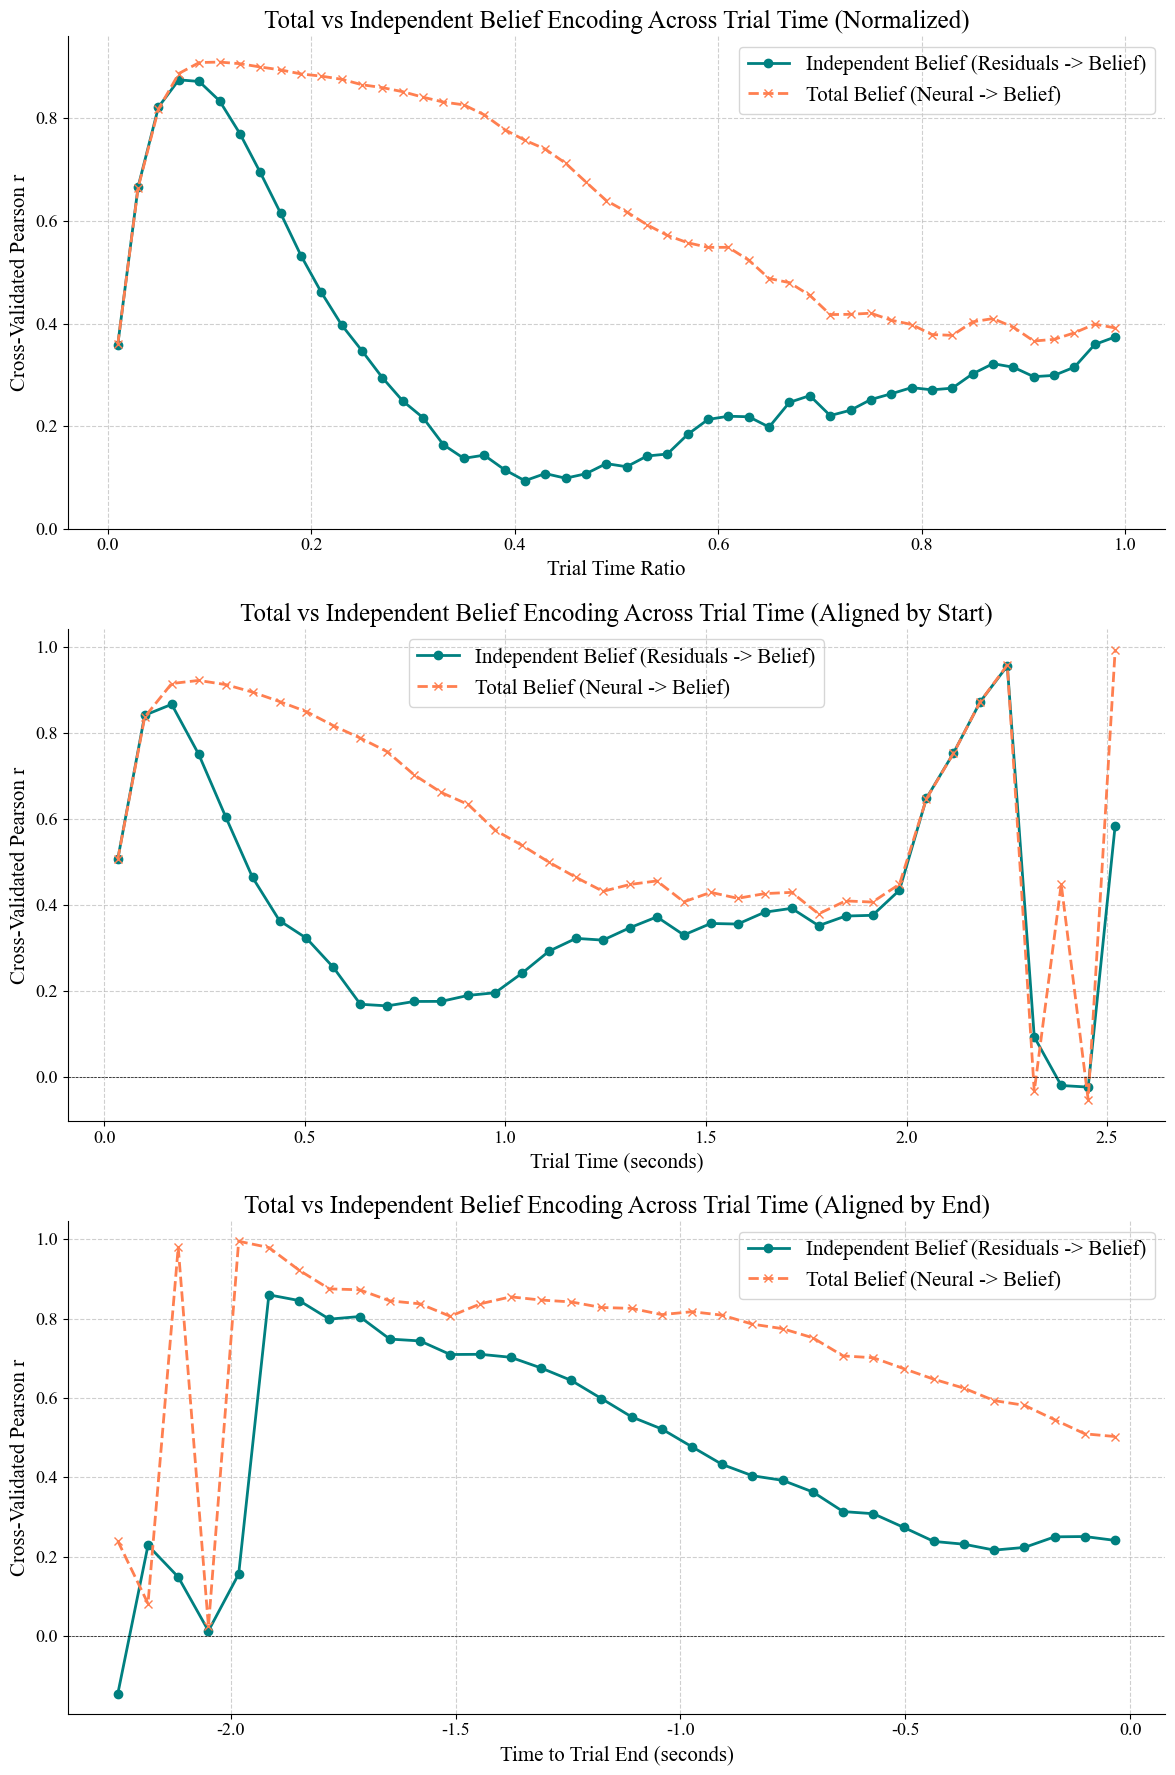


Time-Aligned Analysis Complete.


In [46]:
def analyze_belief_encoding_over_time(timedf, sessdf):
    """
    Analyze how total and independent belief encoding changes over the course of trials.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    
    Returns:
    --------
    None (displays and saves plots)
    """
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from scipy.stats import pearsonr
    from sklearn.model_selection import KFold, cross_val_predict
    from scipy.ndimage import gaussian_filter1d
    
    # --- Parameters ---
    sampling_rate = 166  # Hz - IMPORTANT: Set this to your actual sampling rate
    outlier_threshold_std = 4  # Z-score threshold for removing outliers
    gaussian_sigma_samples = 5  # Std deviation of Gaussian kernel in SAMPLES
    n_time_bins = 50  # Number of bins for timeratio (Adjust if needed)
    min_samples_per_bin = 50  # Minimum samples required in a bin for analysis
    
    # --- Helper function for Z-scoring ---
    def normalize_z(data):
        """Applies z-score normalization to a 1D array."""
        if isinstance(data, pd.Series):
            data = data.to_numpy()
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN/Inf with 0 before scaling
        scaler = StandardScaler()
        if np.std(data) < 1e-9:
            print("Warning: Standard deviation is zero during normalization. Returning zeros.")
            return np.zeros_like(data)
        return scaler.fit_transform(data.reshape(-1, 1)).flatten()
    
    # --- Extract Raw Data ---
    print("--- Extracting Raw Data from DataFrame ---")
    try:
        neural_data_raw_voltage = np.vstack(timedf['PPC'].to_numpy())
        belief_data_present_raw = timedf['belief'].to_numpy()
        eye_data_present_raw = timedf['eye'].to_numpy()
        timeratio_raw = timedf['timeratio'].to_numpy()  # Extract timeratio
        timer_raw = timedf['timer'].to_numpy()  # Extract absolute timer
        countdown_raw = timedf['countdown'].to_numpy()  # Extract countdown timer
        
        print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, "
              f"Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}, "
              f"Timer={timer_raw.shape}, Countdown={countdown_raw.shape}")
    
        if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == 
                timeratio_raw.shape[0] == timer_raw.shape[0] == countdown_raw.shape[0]):
            raise ValueError("Mismatch in number of samples between neural, belief, eye, timeratio, timer, or countdown data.")
    
    except KeyError as e:
        raise KeyError(f"Column not found in timedf: {e}. Ensure all required columns exist.")
    except Exception as e:
        raise TypeError(f"Error processing data columns: {e}")
    
    # --- Normalize Behavioral Data Globally ---
    print("\n--- Normalizing Behavioral Data (Globally) ---")
    belief_data_normalized = normalize_z(belief_data_present_raw)
    eye_data_normalized = normalize_z(eye_data_present_raw)
    
    # --- Outlier Removal (Based on Normalized Belief & Eye) ---
    print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
    task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
    mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)
    
    neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
    belief_data_present = belief_data_normalized[mask_outliers]
    eye_data_present = eye_data_normalized[mask_outliers]
    timeratio_present = timeratio_raw[mask_outliers]
    timer_present = timer_raw[mask_outliers]
    countdown_present = countdown_raw[mask_outliers]
    
    # --- Gaussian Smoothing of Cleaned Raw Voltage Data ---
    print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
    neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                           sigma=gaussian_sigma_samples,
                                           axis=0,
                                           mode='reflect')
    
    # --- Z-score Smoothed Data Per Channel Globally ---
    print("Z-scoring smoothed data per channel (Globally)...")
    neural_data_processed = np.zeros_like(neural_data_smoothed)
    for i in range(neural_data_smoothed.shape[1]):
        channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
        if np.std(channel_data) > 1e-9:
            neural_data_processed[:, i] = normalize_z(channel_data)
    
    # Define a function to perform binned analysis with different time variables
    def perform_binned_analysis(time_variable, time_label, bin_edges=None, n_bins=50):
        print(f"\n--- Time-Binned Analysis for {time_label} ---")
        
        # Calculate bin edges if not provided
        if bin_edges is None:
            min_time = np.min(time_variable)
            max_time = np.max(time_variable)
            bin_edges = np.linspace(min_time, max_time, n_bins + 1)
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        results_r_independent = []  # Pearson r for Residuals -> Belief
        results_r_total = []        # Pearson r for Neural -> Belief
        actual_bin_centers = []     # Store centers only for bins with enough data
        
        # Initialize the base model and CV strategy
        lr_model = LinearRegression()
        n_splits = 5  # CV folds within each bin
        
        for i in range(len(bin_centers)):
            bin_start = bin_edges[i]
            bin_end = bin_edges[i+1]
            is_last_bin = (i == len(bin_centers) - 1)
            
            if is_last_bin:
                bin_mask = (time_variable >= bin_start) & (time_variable <= bin_end)
            else:
                bin_mask = (time_variable >= bin_start) & (time_variable < bin_end)
            
            print(f"\nProcessing Bin {i+1}/{len(bin_centers)} ({time_label}: {bin_start:.2f} to {bin_end:.2f})...")
            
            # Select data for the current bin
            neural_bin = neural_data_processed[bin_mask]
            belief_bin = belief_data_present[bin_mask]
            eye_bin = eye_data_present[bin_mask]
            n_samples_in_bin = len(belief_bin)
            print(f"  Samples in bin: {n_samples_in_bin}")
            
            # Check if enough samples for analysis and CV
            if n_samples_in_bin < max(min_samples_per_bin, n_splits):
                print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
                results_r_independent.append(np.nan)
                results_r_total.append(np.nan)
                continue
            
            # --- Perform CV analyses within the bin ---
            eye_bin_2d = eye_bin.reshape(-1, 1)
            
            # Adjust n_splits if samples < 5 but >= 2
            current_n_splits = n_splits
            if n_samples_in_bin < current_n_splits:
                current_n_splits = max(2, n_samples_in_bin)
                print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
            cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)
            
            # --- 1. Total Belief Encoding (Neural -> Belief) ---
            print("  Calculating Total Belief Encoding (Neural -> Belief)...")
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            
            if np.sum(valid_indices_total) < 2:
                r_total_bin, p_total_bin = np.nan, np.nan
            else:
                r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], 
                                                  predicted_belief_total_cv_bin[valid_indices_total])
            
            print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
            results_r_total.append(r_total_bin)
            
            # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
            print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
            # a. Get CV predictions for Neural ~ Eye within bin
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            # b. Calculate Residuals within bin
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            # c. Get CV predictions for Belief ~ Residuals within bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            # d. Evaluate Belief prediction for this bin
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            
            if np.sum(valid_indices_independent) < 2:
                r_independent_bin, p_independent_bin = np.nan, np.nan
            else:
                r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], 
                                                             predicted_belief_independent_cv_bin[valid_indices_independent])
            
            print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
            results_r_independent.append(r_independent_bin)
            
            # Store bin center if calculations were successful
            actual_bin_centers.append(bin_centers[i])
        
        return actual_bin_centers, results_r_independent, results_r_total, bin_centers, bin_edges
    
    # Create figure with three subplots for the three time alignment methods
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # 1. Perform analysis with normalized timeratio (0-1)
    timeratio_bin_edges = np.linspace(0, 1, n_time_bins + 1)
    timeratio_centers, timeratio_r_independent, timeratio_r_total, timeratio_bin_centers, _ = perform_binned_analysis(
        timeratio_present, "Trial Time Ratio", bin_edges=timeratio_bin_edges)
    
    # 2. Perform analysis with timer (aligned at start, 0)
    # First, normalize timer to start at 0 for each trial
    timer_min = np.min(timer_present)
    timer_max = np.max(timer_present)
    timer_bin_edges = np.linspace(0, timer_max - timer_min, n_time_bins + 1)
    timer_centers, timer_r_independent, timer_r_total, timer_bin_centers, _ = perform_binned_analysis(
        timer_present - timer_min, "Trial Time (s)", bin_edges=timer_bin_edges)
    
    # 3. Perform analysis with countdown (aligned at end, 0)
    # First, normalize countdown so all trials end at 0
    countdown_min = np.min(countdown_present)
    countdown_max = np.max(countdown_present)
    countdown_bin_edges = np.linspace(countdown_min, 0, n_time_bins + 1)
    countdown_centers, countdown_r_independent, countdown_r_total, countdown_bin_centers, _ = perform_binned_analysis(
        countdown_present, "Time to Trial End (s)", bin_edges=countdown_bin_edges)
    
    # Plot the results for the three time variables
    plot_data = [
        (timeratio_centers, timeratio_r_independent, timeratio_r_total, "Trial Time Ratio", axes[0]),
        (np.array(timer_centers) * 0.006, timer_r_independent, timer_r_total, "Trial Time (seconds)", axes[1]),  # Convert dt to seconds
        (np.array(countdown_centers) * 0.006, countdown_r_independent, countdown_r_total, "Time to Trial End (seconds)", axes[2])  # Convert dt to seconds
    ]
    
    for idx, (centers, r_independent, r_total, xlabel, ax) in enumerate(plot_data):
        # Filter out NaN results if bins were skipped
        # Convert all arrays to numpy arrays of the same length
        centers_array = np.array(centers)
        r_independent_array = np.array(r_independent)
        r_total_array = np.array(r_total)
        
        # Make sure all arrays have the same length before applying mask
        min_length = min(len(centers_array), len(r_independent_array), len(r_total_array))
        centers_array = centers_array[:min_length]
        r_independent_array = r_independent_array[:min_length]
        r_total_array = r_total_array[:min_length]
        
        valid_results_mask = ~np.isnan(r_independent_array) & ~np.isnan(r_total_array)
        plot_centers = centers_array[valid_results_mask]
        plot_r_independent = r_independent_array[valid_results_mask]
        plot_r_total = r_total_array[valid_results_mask]
        
        title_map = {
            0: "Total vs Independent Belief Encoding Across Trial Time (Normalized)",
            1: "Total vs Independent Belief Encoding Across Trial Time (Aligned by Start)",
            2: "Total vs Independent Belief Encoding Across Trial Time (Aligned by End)"
        }
        
        if len(plot_centers) > 0:
            # Plot Independent Belief Encoding (Residuals -> Belief)
            ax.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', 
                    label='Independent Belief (Residuals -> Belief)')
            # Plot Total Belief Encoding (Neural -> Belief)
            ax.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', 
                    label='Total Belief (Neural -> Belief)')
            
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Cross-Validated Pearson r')
            ax.set_title(title_map[idx])
            
            # Adjust y-limits based on the range of both plots
            min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05)
            max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05)
            ax.set_ylim(bottom=min_y, top=max_y)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Cross-Validated Pearson r')
            ax.set_title(title_map[idx])
    
    plt.tight_layout()
    plt.savefig('belief_encoding_time_comparison.png', dpi=300)
    plt.show()
    
    print("\nTime-Aligned Analysis Complete.")
    
    return fig

# Call the function
fig = analyze_belief_encoding_over_time(timedf, sessdf)

--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural EMA (alpha=0.4)=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,), Timer=(400117,), Countdown=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---

--- Z-scoring Neural EMA data per channel (Globally) ---

--- Time-Binned Analysis for Trial Time Ratio ---

Processing Bin 1/50 (Trial Time Ratio: 0.00 to 0.02)...
  Samples in bin: 9346
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.2295, p=6.20e-112
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent): 0.2288, p=3.11e-111

Processing Bin 2/50 (Trial Time Ratio: 0.02 to 0.04)...
  Samples in bin: 8598
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.4427, p=0.00e+00
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent):

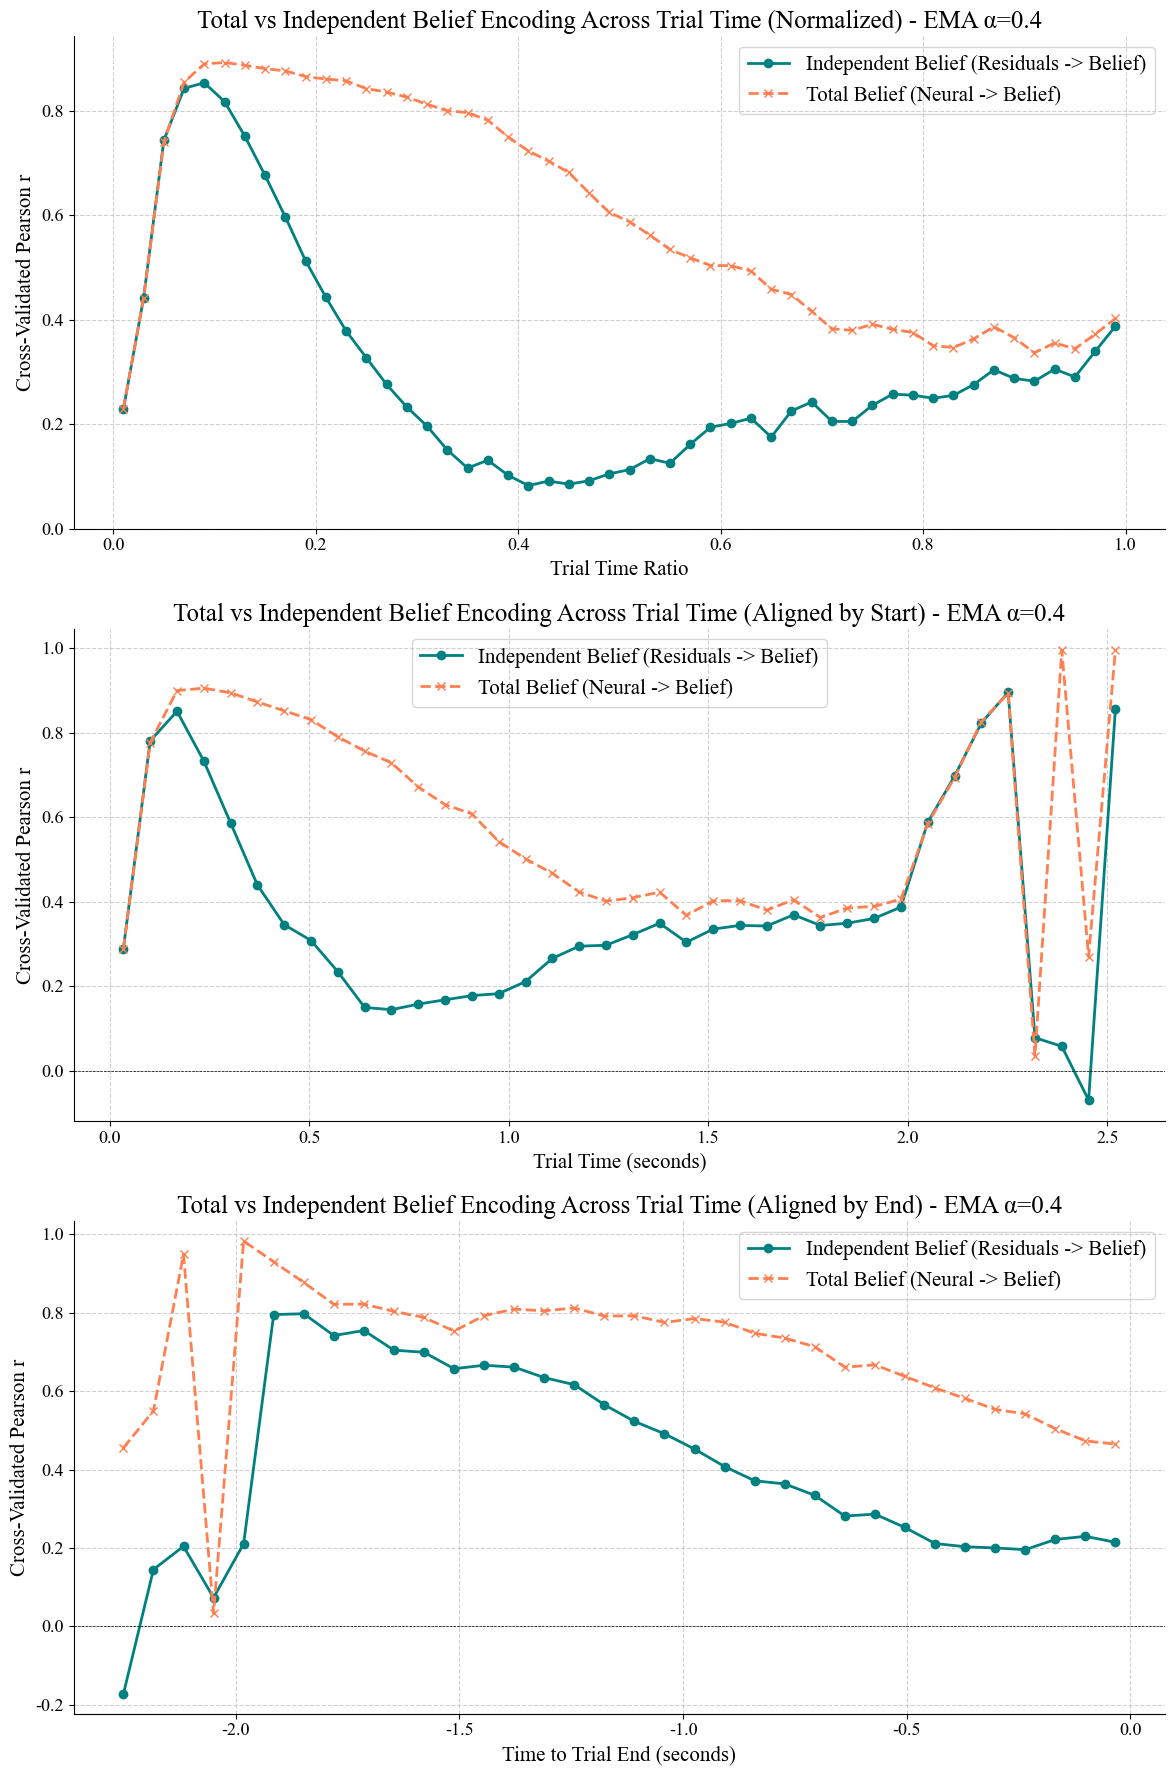


Time-Aligned Analysis Complete using Neural EMA data.


In [49]:
def analyze_belief_encoding_over_time_ema(timedf, sessdf, alpha=0.4):
    """
    Analyze how total and independent belief encoding changes over the course of trials
    using EMA-smoothed neural data.
    
    Parameters:
    -----------
    timedf : DataFrame
        DataFrame containing time-based data
    sessdf : DataFrame
        DataFrame containing session-based data
    alpha : float
        Alpha value used for the EMA smoothing (for documentation purposes)
    
    Returns:
    --------
    None (displays and saves plots)
    """
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from scipy.stats import pearsonr
    from sklearn.model_selection import KFold, cross_val_predict
    from scipy.ndimage import gaussian_filter1d
    
    # --- Parameters ---
    sampling_rate = 166  # Hz - IMPORTANT: Set this to your actual sampling rate
    outlier_threshold_std = 4  # Z-score threshold for removing outliers
    n_time_bins = 50  # Number of bins for timeratio (Adjust if needed)
    min_samples_per_bin = 50  # Minimum samples required in a bin for analysis
    
    # --- Helper function for Z-scoring ---
    def normalize_z(data):
        """Applies z-score normalization to a 1D array."""
        if isinstance(data, pd.Series):
            data = data.to_numpy()
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)  # Replace NaN/Inf with 0 before scaling
        scaler = StandardScaler()
        if np.std(data) < 1e-9:
            print("Warning: Standard deviation is zero during normalization. Returning zeros.")
            return np.zeros_like(data)
        return scaler.fit_transform(data.reshape(-1, 1)).flatten()
    
    # --- Extract Raw Data ---
    print("--- Extracting Raw Data from DataFrame ---")
    try:
        # Use neuralEMA instead of PPC
        neural_data_raw = np.vstack(timedf['neuralEMA'].to_numpy())
        belief_data_present_raw = timedf['belief'].to_numpy()
        eye_data_present_raw = timedf['eye'].to_numpy()
        timeratio_raw = timedf['timeratio'].to_numpy()  # Extract timeratio
        timer_raw = timedf['timer'].to_numpy()  # Extract absolute timer
        countdown_raw = timedf['countdown'].to_numpy()  # Extract countdown timer
        
        print(f"Initial shapes: Neural EMA (alpha={alpha})={neural_data_raw.shape}, Belief={belief_data_present_raw.shape}, "
              f"Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}, "
              f"Timer={timer_raw.shape}, Countdown={countdown_raw.shape}")
    
        if not (neural_data_raw.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == 
                timeratio_raw.shape[0] == timer_raw.shape[0] == countdown_raw.shape[0]):
            raise ValueError("Mismatch in number of samples between neural, belief, eye, timeratio, timer, or countdown data.")
    
    except KeyError as e:
        raise KeyError(f"Column not found in timedf: {e}. Ensure all required columns exist.")
    except Exception as e:
        raise TypeError(f"Error processing data columns: {e}")
    
    # --- Normalize Behavioral Data Globally ---
    print("\n--- Normalizing Behavioral Data (Globally) ---")
    belief_data_normalized = normalize_z(belief_data_present_raw)
    eye_data_normalized = normalize_z(eye_data_present_raw)
    
    # --- Outlier Removal (Based on Normalized Belief & Eye) ---
    print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
    task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
    mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)
    
    neural_data_cleaned = neural_data_raw[mask_outliers, :]
    belief_data_present = belief_data_normalized[mask_outliers]
    eye_data_present = eye_data_normalized[mask_outliers]
    timeratio_present = timeratio_raw[mask_outliers]
    timer_present = timer_raw[mask_outliers]
    countdown_present = countdown_raw[mask_outliers]
    
    # --- Z-score Neural EMA Data Per Channel Globally ---
    print("\n--- Z-scoring Neural EMA data per channel (Globally) ---")
    neural_data_processed = np.zeros_like(neural_data_cleaned)
    for i in range(neural_data_cleaned.shape[1]):
        channel_data = neural_data_cleaned[:, i].reshape(-1, 1)
        if np.std(channel_data) > 1e-9:
            neural_data_processed[:, i] = normalize_z(channel_data)
    
    # Define a function to perform binned analysis with different time variables
    def perform_binned_analysis(time_variable, time_label, bin_edges=None, n_bins=50):
        print(f"\n--- Time-Binned Analysis for {time_label} ---")
        
        # Calculate bin edges if not provided
        if bin_edges is None:
            min_time = np.min(time_variable)
            max_time = np.max(time_variable)
            bin_edges = np.linspace(min_time, max_time, n_bins + 1)
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        results_r_independent = []  # Pearson r for Residuals -> Belief
        results_r_total = []        # Pearson r for Neural -> Belief
        actual_bin_centers = []     # Store centers only for bins with enough data
        
        # Initialize the base model and CV strategy
        lr_model = LinearRegression()
        n_splits = 5  # CV folds within each bin
        
        for i in range(len(bin_centers)):
            bin_start = bin_edges[i]
            bin_end = bin_edges[i+1]
            is_last_bin = (i == len(bin_centers) - 1)
            
            if is_last_bin:
                bin_mask = (time_variable >= bin_start) & (time_variable <= bin_end)
            else:
                bin_mask = (time_variable >= bin_start) & (time_variable < bin_end)
            
            print(f"\nProcessing Bin {i+1}/{len(bin_centers)} ({time_label}: {bin_start:.2f} to {bin_end:.2f})...")
            
            # Select data for the current bin
            neural_bin = neural_data_processed[bin_mask]
            belief_bin = belief_data_present[bin_mask]
            eye_bin = eye_data_present[bin_mask]
            n_samples_in_bin = len(belief_bin)
            print(f"  Samples in bin: {n_samples_in_bin}")
            
            # Check if enough samples for analysis and CV
            if n_samples_in_bin < max(min_samples_per_bin, n_splits):
                print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
                results_r_independent.append(np.nan)
                results_r_total.append(np.nan)
                continue
            
            # --- Perform CV analyses within the bin ---
            eye_bin_2d = eye_bin.reshape(-1, 1)
            
            # Adjust n_splits if samples < 5 but >= 2
            current_n_splits = n_splits
            if n_samples_in_bin < current_n_splits:
                current_n_splits = max(2, n_samples_in_bin)
                print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
            cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)
            
            # --- 1. Total Belief Encoding (Neural -> Belief) ---
            print("  Calculating Total Belief Encoding (Neural -> Belief)...")
            predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
            valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
            
            if np.sum(valid_indices_total) < 2:
                r_total_bin, p_total_bin = np.nan, np.nan
            else:
                r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], 
                                                  predicted_belief_total_cv_bin[valid_indices_total])
            
            print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
            results_r_total.append(r_total_bin)
            
            # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
            print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
            # a. Get CV predictions for Neural ~ Eye within bin
            predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
            # b. Calculate Residuals within bin
            residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
            # c. Get CV predictions for Belief ~ Residuals within bin
            predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
            # d. Evaluate Belief prediction for this bin
            valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
            
            if np.sum(valid_indices_independent) < 2:
                r_independent_bin, p_independent_bin = np.nan, np.nan
            else:
                r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], 
                                                             predicted_belief_independent_cv_bin[valid_indices_independent])
            
            print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
            results_r_independent.append(r_independent_bin)
            
            # Store bin center if calculations were successful
            actual_bin_centers.append(bin_centers[i])
        
        return actual_bin_centers, results_r_independent, results_r_total, bin_centers, bin_edges
    
    # Create figure with three subplots for the three time alignment methods
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # 1. Perform analysis with normalized timeratio (0-1)
    timeratio_bin_edges = np.linspace(0, 1, n_time_bins + 1)
    timeratio_centers, timeratio_r_independent, timeratio_r_total, timeratio_bin_centers, _ = perform_binned_analysis(
        timeratio_present, "Trial Time Ratio", bin_edges=timeratio_bin_edges)
    
    # 2. Perform analysis with timer (aligned at start, 0)
    # First, normalize timer to start at 0 for each trial
    timer_min = np.min(timer_present)
    timer_max = np.max(timer_present)
    timer_bin_edges = np.linspace(0, timer_max - timer_min, n_time_bins + 1)
    timer_centers, timer_r_independent, timer_r_total, timer_bin_centers, _ = perform_binned_analysis(
        timer_present - timer_min, "Trial Time (s)", bin_edges=timer_bin_edges)
    
    # 3. Perform analysis with countdown (aligned at end, 0)
    # First, normalize countdown so all trials end at 0
    countdown_min = np.min(countdown_present)
    countdown_max = np.max(countdown_present)
    countdown_bin_edges = np.linspace(countdown_min, 0, n_time_bins + 1)
    countdown_centers, countdown_r_independent, countdown_r_total, countdown_bin_centers, _ = perform_binned_analysis(
        countdown_present, "Time to Trial End (s)", bin_edges=countdown_bin_edges)
    
    # Plot the results for the three time variables
    plot_data = [
        (timeratio_centers, timeratio_r_independent, timeratio_r_total, "Trial Time Ratio", axes[0]),
        (np.array(timer_centers) * 0.006, timer_r_independent, timer_r_total, "Trial Time (seconds)", axes[1]),  # Convert dt to seconds
        (np.array(countdown_centers) * 0.006, countdown_r_independent, countdown_r_total, "Time to Trial End (seconds)", axes[2])  # Convert dt to seconds
    ]
    
    for idx, (centers, r_independent, r_total, xlabel, ax) in enumerate(plot_data):
        # Filter out NaN results if bins were skipped
        # Convert all arrays to numpy arrays of the same length
        centers_array = np.array(centers)
        r_independent_array = np.array(r_independent)
        r_total_array = np.array(r_total)
        
        # Make sure all arrays have the same length before applying mask
        min_length = min(len(centers_array), len(r_independent_array), len(r_total_array))
        centers_array = centers_array[:min_length]
        r_independent_array = r_independent_array[:min_length]
        r_total_array = r_total_array[:min_length]
        
        valid_results_mask = ~np.isnan(r_independent_array) & ~np.isnan(r_total_array)
        plot_centers = centers_array[valid_results_mask]
        plot_r_independent = r_independent_array[valid_results_mask]
        plot_r_total = r_total_array[valid_results_mask]
        
        title_map = {
            0: f"Total vs Independent Belief Encoding Across Trial Time (Normalized) - EMA α={alpha}",
            1: f"Total vs Independent Belief Encoding Across Trial Time (Aligned by Start) - EMA α={alpha}",
            2: f"Total vs Independent Belief Encoding Across Trial Time (Aligned by End) - EMA α={alpha}"
        }
        
        if len(plot_centers) > 0:
            # Plot Independent Belief Encoding (Residuals -> Belief)
            ax.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', 
                    label='Independent Belief (Residuals -> Belief)')
            # Plot Total Belief Encoding (Neural -> Belief)
            ax.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', 
                    label='Total Belief (Neural -> Belief)')
            
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Cross-Validated Pearson r')
            ax.set_title(title_map[idx])
            
            # Adjust y-limits based on the range of both plots
            min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05)
            max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05)
            ax.set_ylim(bottom=min_y, top=max_y)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Cross-Validated Pearson r')
            ax.set_title(title_map[idx])
    
    plt.tight_layout()
    plt.savefig(f'belief_encoding_time_comparison_ema_{alpha}.png', dpi=300)
    plt.show()
    
    print("\nTime-Aligned Analysis Complete using Neural EMA data.")
    
    return fig

# Call the function
fig = analyze_belief_encoding_over_time_ema(timedf, sessdf, alpha=0.4)

In [50]:
notify()

(array([14.61817991,  2.7121376 ,  2.23114371,  0.95659151,  0.68709472,
         0.33446814,  0.20820157,  0.10986715,  0.06380051,  0.03336197,
         0.04515261]),
 array([0.        , 0.04545455, 0.09090909, 0.13636364, 0.18181819,
        0.22727273, 0.27272728, 0.31818181, 0.36363637, 0.40909091,
        0.45454547, 0.5       ]),
 <BarContainer object of 11 artists>)

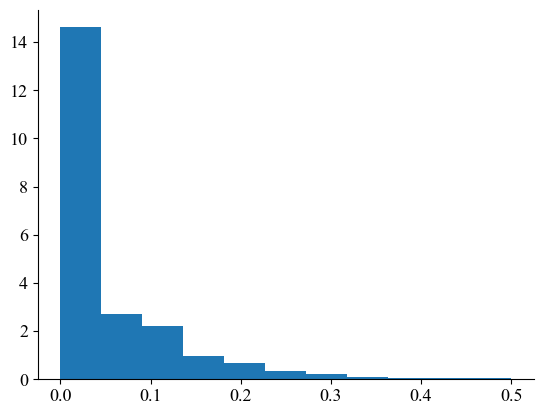

In [60]:
neural_data_raw_voltage = np.vstack(timedf['PPC'].to_numpy())
plt.hist(np.concatenate(neural_data_raw_voltage).clip(0,0.5), bins=11, density=True)